In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, BatchNormalization
import keras
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.utils import resample
import tensorflow as tf
import seaborn as sns
import random
import shap

In [66]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

df_predictors = pd.read_excel('/content/Extended Data_predictors.xlsx')
print(df_predictors.shape)
print(df_predictors.head())

df_target = pd.read_excel('/content/Extended Data_response.xlsx')
print(df_target.shape)
print(df_target.head())

df_full = df_predictors.copy()
df_full['Kc'] = df_target['Kc']

print(df_full.head())

# Проверка на пропуски
print(f"\nПропуски в данных:\n{df_full.isnull().sum()}")

# Разделение 80/20
train_df, test_df = train_test_split(df_full, test_size=0.2, stratify=df_full['P'], random_state=42)

print(f"Обучающая выборка: {len(train_df)} строк (80%)")
print(f"Тестовая выборка: {len(test_df)} строк (20%)")

# Отделяем предикторы (X) от целевой переменной (y)
X_train = train_df[['a', 'c', 'P']].values
y_train = train_df['Kc'].values

X_test = test_df[['a', 'c', 'P']].values
y_test = test_df['Kc'].values

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

(30000, 4)
           a      c        P       c/a
0  15.630000  49.05  27.3715  3.138196
1  15.860152  49.05  27.3715  3.092656
2  16.090303  49.05  27.3715  3.048420
3  16.320455  49.05  27.3715  3.005431
4  16.550606  49.05  27.3715  2.963638
(30000, 1)
         Kc
0  0.735192
1  0.757003
2  0.779132
3  0.801581
4  0.824348
           a      c        P       c/a        Kc
0  15.630000  49.05  27.3715  3.138196  0.735192
1  15.860152  49.05  27.3715  3.092656  0.757003
2  16.090303  49.05  27.3715  3.048420  0.779132
3  16.320455  49.05  27.3715  3.005431  0.801581
4  16.550606  49.05  27.3715  2.963638  0.824348

Пропуски в данных:
a      0
c      0
P      0
c/a    0
Kc     0
dtype: int64
Обучающая выборка: 24000 строк (80%)
Тестовая выборка: 6000 строк (20%)
Обучающая выборка: (24000, 3)
Тестовая выборка: (6000, 3)


In [67]:
# Набор стратегий для K-Fold кросс-валидации
strategies = [
    {'name': 'A', 'layers': 3, 'neurons': 64, 'activation': 'tanh'},
    {'name': 'B', 'layers': 2, 'neurons': 64, 'activation': 'relu'},
    {'name': 'C', 'layers': 3, 'neurons': 32, 'activation': 'tanh'},
    {'name': 'D', 'layers': 2, 'neurons': 32, 'activation': 'relu'},
    {'name': 'E', 'layers': 3, 'neurons': 64, 'activation': 'relu'}
]

In [68]:
# Функция для создания модели
def build_model(layers, neurons, activation):
    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_shape=(3,)))

    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(0.5))

    model.add(Dense(1, activation='elu'))  # регрессия

    model.compile(loss='mean_squared_error', optimizer='adam')

    return model

In [69]:
# K-Fold кросс-валидация
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for strategy in strategies: # Провекра всех гиперпараметров
    print(f"\nПроверяем стратегию {strategy['name']}...")

    fold_mse = []
    fold_mae = []
    fold_r2 = []

    for train_idx, val_idx in kf.split(X_train): # Разделение выборки
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        model = build_model(
            strategy['layers'],
            strategy['neurons'],
            strategy['activation']
        )

        model.fit(X_tr, y_tr, epochs=30, batch_size=32, verbose=0)

        y_pred = model.predict(X_val, verbose=0)
        mse = mean_squared_error(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

# Добавление модели и ее результатов в словарь
    results.append({
        'name': strategy['name'],
        'layers': strategy['layers'],
        'neurons': strategy['neurons'],
        'activation': strategy['activation'],
        'mean_mse': avg_mse
    })

    print(f"MSE: {avg_mse:.4f}")
    print(f"MAE: {avg_mae:.4f}")
    print(f"R2: {avg_r2:.4f}")


Проверяем стратегию A...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0049
MAE: 0.0459
R2: 0.9593

Проверяем стратегию B...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0029
MAE: 0.0394
R2: 0.9758

Проверяем стратегию C...


...

MSE: 0.0070
MAE: 0.0556
R2: 0.9414

Проверяем стратегию D...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0025
MAE: 0.0322
R2: 0.9787

Проверяем стратегию E...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0022
MAE: 0.0314
R2: 0.9817


In [70]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='mean_mse') # Сортировка по среднему MSE

print("\nВсе стратегии:")
print(results_df)

print("\nЛУЧШАЯ СТРАТЕГИЯ:")
print(results_df.iloc[0])


Все стратегии:
  name  layers  neurons activation  mean_mse
4    E       3       64       relu  0.002188
3    D       2       32       relu  0.002547
1    B       2       64       relu  0.002892
0    A       3       64       tanh  0.004856
2    C       3       32       tanh  0.006996

ЛУЧШАЯ СТРАТЕГИЯ:
name                 E
layers               3
neurons             64
activation        relu
mean_mse      0.002188
Name: 4, dtype: object


In [71]:
# Масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [72]:
value = df_full['P'].unique() # Значения пористости
n_models = 10
models = []
mse_list = []
X_testm = []
y_testm = []

# Разбиение выборки по разной пористости
for i in value:
    df_test = test_df[test_df['P'] == i].copy()

    X_test1 = df_test[['a', 'c', 'P']].values
    X_test1 = scaler.transform(X_test1)

    X_testm.append(X_test1)
    y_testm.append(df_test['Kc'].values)

# Обучение 10 нейронных сетей
for i in range(n_models):
    print(f"Модель {i+1}")

    X_boot, y_boot = resample(X_train, y_train, replace=True) # Создание бутстрап-выборки

    model = build_model(int(results_df.iloc[0, 1]), int(results_df.iloc[0, 2]), results_df.iloc[0, 3]) # Создание модели с лучшими гиперпараметрами

    model.fit(X_boot, y_boot, epochs=30, batch_size=32, verbose=0)

    mse_con = []
    mae_con = []
    r2_con = []

    for i in range(3): # Предсказание для разной пористости
        y_pred = model.predict(X_testm[i], verbose=0)

        mse_con.append(mean_squared_error(y_testm[i], y_pred))
        mae_con.append(mean_absolute_error(y_testm[i], y_pred))
        r2_con.append(r2_score(y_testm[i], y_pred))
        print(f"mse({value[i]}): {mse_con[i]:.6f}")

    mse = np.mean(mse_con)
    mae = np.mean(mae_con)
    r2 = np.mean(r2_con)
    models.append(model)
    mse_list.append(mse)

    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")

Модель 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000937
mse(23.01): 0.001175
mse(7.96274): 0.002287
MSE: 0.001466
MAE: 0.0239
R2: 0.9874
Модель 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.001100
mse(23.01): 0.001409
mse(7.96274): 0.002959
MSE: 0.001823
MAE: 0.0286
R2: 0.9844
Модель 3


...

mse(27.3715): 0.001354
mse(23.01): 0.001801
mse(7.96274): 0.002221
MSE: 0.001792
MAE: 0.0272
R2: 0.9841
Модель 9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000629
mse(23.01): 0.001002
mse(7.96274): 0.001633
MSE: 0.001088
MAE: 0.0205
R2: 0.9906
Модель 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000737
mse(23.01): 0.000730
mse(7.96274): 0.001844
MSE: 0.001104
MAE: 0.0190
R2: 0.9905


In [73]:
# Выявление 5 лучших моделей
best_indices = np.argsort(mse_list)[:5]
best_models = [models[i] for i in best_indices]

mse = []
mae = []
r2 = []
mse_data = []

# Предсказание на 5 лучших моделях и объединение их в ансамбль
for i in range(3):
    pred_con = []

    for model in best_models:
        pred = model.predict(X_testm[i], verbose=0)
        mse_data.append(mean_squared_error(y_testm[i], pred))
        pred_con.append(pred)

    predictions = np.mean(pred_con, axis=0)
    mse.append(mean_squared_error(y_testm[i], predictions))
    mae.append(mean_absolute_error(y_testm[i], predictions))
    r2.append(r2_score(y_testm[i], predictions))
    print(f"MSE({value[i]}): {mse[i]:.6f}")

ensemble_mse = np.mean(mse)
ensemble_mae = np.mean(mae)
ensemble_r2 = np.mean(r2)

print(f"Ансамбль MSE: {ensemble_mse:.6f}")
print(f"Ансамбль MAE: {ensemble_mae:.6f}")
print(f"Ансамбль R2: {ensemble_r2:.6f}")

MSE(27.3715): 0.000364
MSE(23.01): 0.000448
MSE(7.96274): 0.001211
Ансамбль MSE: 0.000674
Ансамбль MAE: 0.011691
Ансамбль R2: 0.994328


In [74]:
data = []

# Построение датафрейма с результатами моделей
for i in range(5):
    j = (mse_data[i] + mse_data[i+5] + mse_data[i+10])/3
    data.append({"Модель": best_indices[i]+1,
            "0.0%": mse_data[i],
            "0.1%": mse_data[i+5],
            "0.5%": mse_data[i+10],
            "MSE": j})

result_df = pd.DataFrame(data)
print(result_df)

   Модель      0.0%      0.1%      0.5%       MSE
0       6  0.000678  0.000651  0.001631  0.000987
1       9  0.000629  0.001002  0.001633  0.001088
2      10  0.000737  0.000730  0.001844  0.001104
3       3  0.000887  0.001032  0.001751  0.001223
4       4  0.001160  0.001178  0.001847  0.001395


In [75]:
# Формирование новой выборки для прогнозирования поверхностей K_IC (P,a,c) для концентраций МУНТ от 0.0 до 0.5 масс.%
MWCNT_con = np.arange(0, 0.51, 0.01)
P_con = np.linspace(max(value), min(value), len(MWCNT_con))
a = np.linspace(15.63, 38.415, 100)
c = np.linspace(49.05, 108.24, 100)

data = []
for i in P_con:
    for j in c:
        for n in a:
            data.append({"a": n,
                    "c": j,
                    "P": i})

new_X = pd.DataFrame(data)

new_X1 = scaler.transform(new_X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [76]:
ensemble_pred = []
pred_mean = []

# Предсказание модлей на новой выборке
for model in best_models:
    pred = model.predict(new_X1, verbose=0)
    predictions = []
    for i in P_con:
        df_test = new_X.copy()
        df_test['Kc'] = pred
        df_test = df_test[df_test['P'] == i].copy()
        q = df_test['Kc'].values

        predictions.append(np.mean(q))

    pred_mean.append(predictions)

ensemble_pred = np.mean(pred_mean, axis=0)

hg = []

# Расчет исходных экспериментальных данных
for i in value:
    df_test = df_full.copy()
    df_test = df_test[df_test['P'] == i].copy()
    hg.append(np.mean(df_test['Kc'].values))

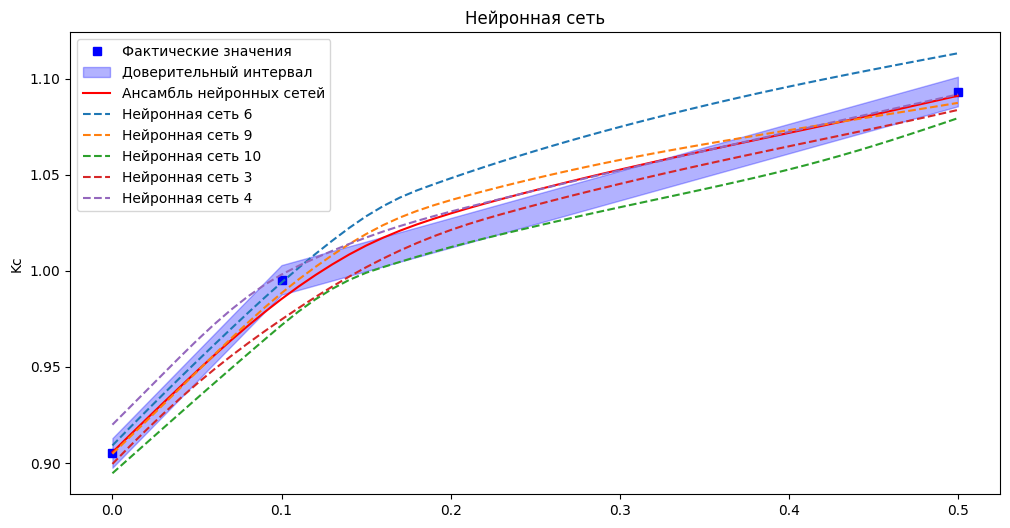

In [77]:
# Построение графиков
plt.figure(figsize=(12, 6))
x_points = MWCNT_con
y_points = ensemble_pred
x_points1 = [0, 0.1, 0.5]
y_points1 = hg
ci = 0.1 * np.std(y_points1) / np.mean(y_points1)
plt.plot(x_points1, y_points1, marker ='s', linestyle ='', color='blue', label='Фактические значения')
plt.fill_between(x_points1, (y_points1-ci), (y_points1+ci), color='blue', alpha=0.3, label='Доверительный интервал')
plt.plot(x_points, y_points, color='red', label='Ансамбль нейронных сетей')
for i in range(5):
    plt.plot(x_points, pred_mean[i], linestyle ='--', label=f'Нейронная сеть {best_indices[i]+1}')
plt.ylabel('Kc')
plt.title('Нейронная сеть')
plt.legend()
plt.show()

In [ ]:
# Подготовка данных для DeepExplainer
X_train_sample = shap.sample(X_train, 5000)
X_test_sample = shap.sample(X_test, 1000)
shap_mean = []

# Расчет shap_values для ансамбля нейронных сетей
for model in best_models:
    explainer = shap.KernelExplainer(model, X_train_sample)
    shap_values = explainer.shap_values(X_test_sample)
    shap_values = np.array(shap_values).squeeze()
    shap_mean.append(shap_values)

shap_values = np.mean(shap_mean, axis=0)

/tmp/ipykernel_20054/992168724.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar",


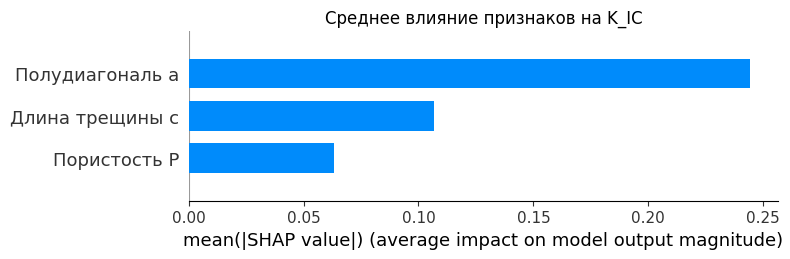

ОТНОСИТЕЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:
   • Полудиагональ a: 59.0% от общего влияния на K_IC
   • Длина трещины c: 25.8% от общего влияния на K_IC
   • Пористость P: 15.2% от общего влияния на K_IC


In [79]:
feature_names = ['Полудиагональ a', 'Длина трещины c', 'Пористость P']

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
        feature_names=feature_names,
        show=False,
        max_display=len(feature_names)
    )
plt.title('Среднее влияние признаков на K_IC', fontsize=12)
plt.tight_layout()

plt.show()

# Относительная важность
mean_shap = np.mean(np.abs(shap_values), axis=0)

print("ОТНОСИТЕЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:")
total_impact = np.sum(np.abs(mean_shap))
for i, feature in enumerate(feature_names):
    relative_impact = np.abs(mean_shap[i]) / total_impact * 100
    print(f"   • {feature}: {relative_impact:.1f}% от общего влияния на K_IC")

По графику и расчетам видно, что наибольшее влияние на трещиностойкость оказывает полудиагональ отпечатка индентора, чуть меньшее - длина трещины, и еще меньше влияет пористость. Для более детального анализа был построен следующий график.

/tmp/ipykernel_20054/161256510.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample,


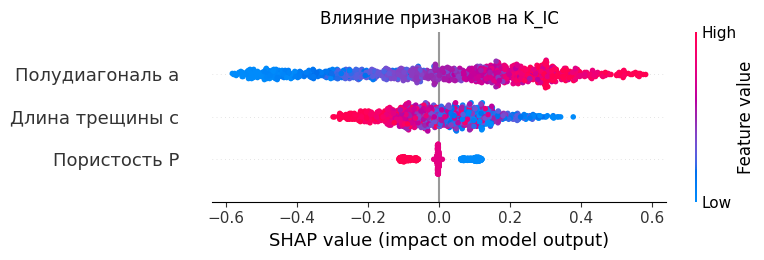

In [80]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample,
        feature_names=feature_names,
        show=False,
        max_display=len(feature_names)
    )
plt.title('Влияние признаков на K_IC', fontsize=12)
plt.tight_layout()

plt.show()

На данном графике чем меньше значение признака, тем ближе цвет к синему, чем оно больше, тем ближе цвет к красному. Также по длине графика можно определить его влияние на целевую переменную.
- Полудиагональ a показывает большее влияние K_IC, так как график распределения длинее. По цвету можно определить, что при росте длины полудиагонали трещиностойкость увеличивается.
- Длина трещины c оказывает меньшее влияние на целевую переменную. При этом обладает обратной зависимостью: чем больше длина трещины, тем меньше трещиностойкость.
- Пористость P оказывает наименьшее влияние относительно других признаков. Этот признак также имеет обратное влияние на трещиностойкость: чем он меньше, тем она больше.   

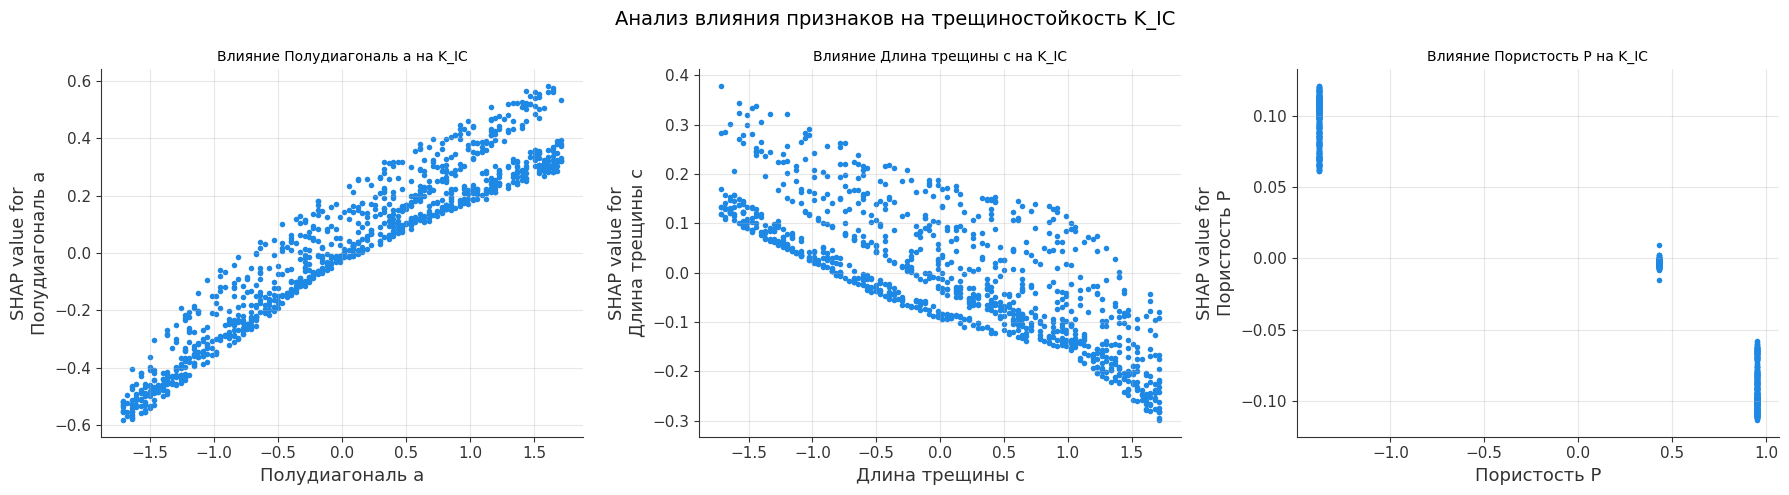

In [81]:
n_features = len(feature_names)
fig, axes = plt.subplots(1, n_features, figsize=(6*n_features, 5))

if n_features == 1:
    axes = [axes]

for idx, feature in enumerate(feature_names):
    shap.dependence_plot(
        idx, shap_values, X_test_sample,
        feature_names=feature_names,
        ax=axes[idx], show=False,
        interaction_index=None
        )
    axes[idx].set_title(f'Влияние {feature} на K_IC', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Анализ влияния признаков на трещиностойкость K_IC', fontsize=14)
plt.tight_layout()

plt.show()

На данном графике наглядно видно, что при увеличении полудиагонали a трещиностойкость возрастает, а при увеличении длины трещины c и пористости P она уменьшается.

Выводы:

- Так как полудиагональ появляется в результате эксперимента, в котором на каждом образце выполнялись вдавливания алмазной пирамидой Виккерса, при большей трещиностойкости пирамида могла оставить больший след до появления трещин, поэтому можно наблюдать именно такое влияние признака a на целевую переменную.
- Длина трещины, полученная в результате, также зависит от трещиностойкости: чем она больше, тем меньше должны быть трещины.
- Поскольку пористость напрямую зависит от концентрации МУНТ в образце (чем больше концентрация МУНТ, тем меньше пористость), уменьшение значения пористости указывает на большую концентрацию МУНТ, следовательно, на большую трещиностойкость.